# Appendix. Cloud Sync: One Memory, Many Devices

Every lesson so far kept memory on the device. This appendix shows the one path memory takes off the device: push your memory to your own Qdrant Cloud cluster, pull the whole memory onto a second device, then pull only what changed.

Section 1 builds the memory used here, so the notebook runs from a fresh kernel.

## 1. Build the memory on this device

In [ ]:
from helper import *
from qdrant_edge import EdgeShard, Point, UpdateOperation

sync_shard = new_shard("./sync_shard", text=768, image=512)

day, history, notes, photos = load_day_and_history()
store_notes(sync_shard, notes, preview=False)
store_photo_memories(sync_shard, photos,
                     "./ro_shared_data/images", preview=False)
sync_shard.optimize()

print(f"{sync_shard.info().points_count} memories on this device.")

## 2. Set up a Qdrant Cloud cluster

Create a free cluster at [cloud.qdrant.io](https://cloud.qdrant.io/signup). Open **Clusters**, select **Create a Free Cluster**, and choose the region closest to you. The free tier covers this lesson and asks for no card.

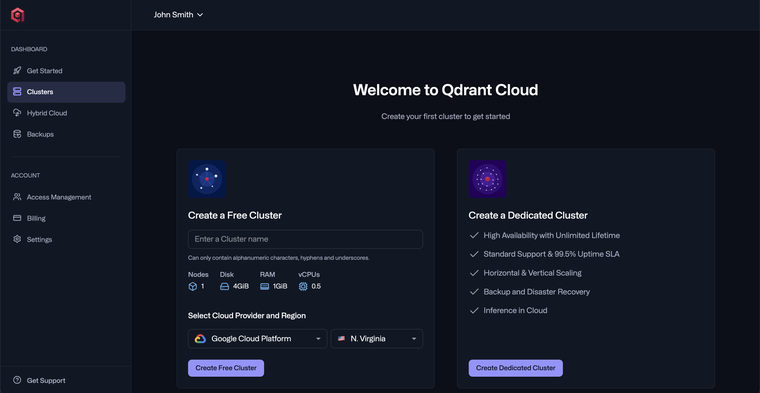

Qdrant shows the API key once when the cluster is created. Copy it then, because you cannot read the full key again. The cluster URL is on the same page under **the API**, and ends in `:6333`.

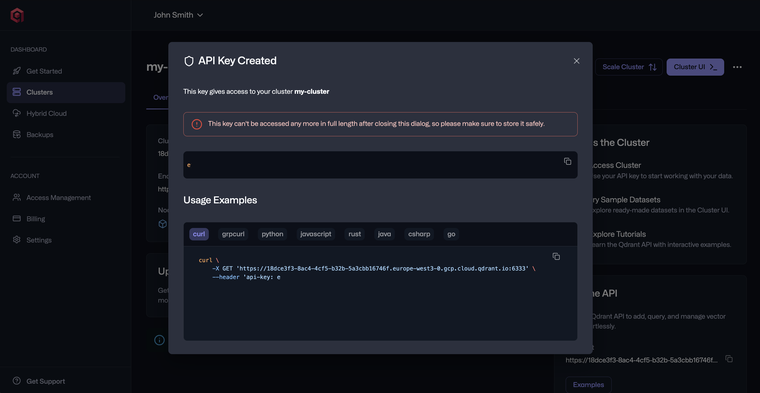

Paste the URL and the key into the cell below. Filling them in is what turns syncing on, so there is no second switch to remember. Keep the key out of any notebook you share.

Leave them empty and every section below still runs, saying what it would have done while your memory stays on the device.

In [ ]:
import os

# Paste your cluster's URL and key to turn syncing on.
# The URL looks like https://<id>.<region>.cloud.qdrant.io:6333
os.environ["QDRANT_URL"] = ""
os.environ["QDRANT_API_KEY"] = ""

## 3. Push this device's memory to the cloud

Uploading your memory is a deliberate choice: it happens only once your credentials are in place. The upload sends the same points the shard holds on the device, vectors and payloads together.

In [ ]:
client = cloud_client("assistant_memory")

if client is None:
    print("Nothing uploaded. Every memory stays on this device.")
else:
    points = cloud_points(sync_shard)

    client.upsert("assistant_memory", points=points)
    print(f"Pushed {len(points)} memories.")

## 4. Pull the memory onto a second device

Device B starts as a new device with no history. It downloads one snapshot, loads the shard, and answers a question about a day it never saw.

Device B only reads here. In a real fleet both devices also write, which is the pattern the closing section links to.

In [ ]:
if client is None:
    print("No cluster configured. Every memory stays on this device.")
else:
    DEVICE_B = fresh_start("./device_b_shard")
    snapshot = fetch_snapshot("assistant_memory",
                              "./assistant.snapshot")
    EdgeShard.unpack_snapshot(snapshot, DEVICE_B)
    device_b = EdgeShard.load(DEVICE_B)

    print("Whole memory:", file_size(snapshot))
    hit = text_search(device_b, "the ramen place downtown", limit=1)[0]
    print(f"Device B recalls your day: {hit.score:.3f} ",
          hit.payload.get("note") or hit.payload["transcript"])
    print(device_b.info().points_count,
          "memories, none captured here.")

## 5. Pull only new memories

Device B sends its manifest, a short list of the segment files it already holds. The server compares that list with the cluster and builds a snapshot of the difference alone. Compare the two printed sizes: that gap is why partial snapshots exist.

In [ ]:
if client is None:
    print("No cluster configured. Every memory stays on this device.")
else:
    push_note(client, "assistant_memory", 6000,
              "The spare batteries are in the charging dock")

    manifest = device_b.snapshot_manifest()
    partial = fetch_snapshot("assistant_memory",
                             "./partial.snapshot",
                             manifest=manifest)
    device_b.update_from_snapshot(partial)

    print("Only what changed:", file_size(partial))
    hit = text_search(device_b, "where are the spare batteries?",
                      limit=1)[0]
    print(f"Device B has it: {hit.score:.3f} ", hit.payload["note"])

## 6. Write locally, answer from both

A device in a fleet does two things at once: it captures memories of its own, and it holds what the fleet already knows. Those go in two shards. The mirror you have been refreshing is read-only and comes from the cluster. A second shard takes this device's own writes, so they are searchable here immediately.

Each new memory is written twice: into the local shard, and up to the cluster for everyone else. A question then searches both shards, and the merge keeps the better score whenever the same memory turns up in each.

In [ ]:
def recall_both(question, shards, limit=3):
    hits = []
    for shard in shards:
        hits += text_search(shard, question, limit=limit)

    # The same memory can sit in both shards, so keep its better score.
    best = {}
    for hit in hits:
        if hit.id not in best or hit.score > best[hit.id].score:
            best[hit.id] = hit
    return sorted(best.values(), key=lambda h: h.score,
                  reverse=True)[:limit]

In [ ]:
if client is None:
    print("No cluster configured. Every memory stays on this device.")
else:
    local = new_shard("./device_b_local", text=768, image=512)

    note = "Charging dock is on the north wall"
    note_vector = embed_text([note])[0]
    payload = {"source_type": "text", "note": note}

    local.update(UpdateOperation.upsert_points([
        Point(id=7000, vector={"text": note_vector}, payload=payload),
    ]))
    local.optimize()
    push_note(client, "assistant_memory", 7000, note)

    answers = recall_both("where is the charging dock?",
                          [device_b, local])
    results_table(answers, "Both shards, merged")

## Where this goes

This push-pull loop is the pattern behind fleet memory: every device pushes what it learns, every device pulls what the fleet knows. The production version keeps two shards per device (a mutable one for local writes, a mirrored one refreshed by partial snapshots) and is documented in the [Edge synchronization guide](https://qdrant.tech/documentation/edge/edge-synchronization-guide/), with a reference implementation in [qdrant-edge-demo](https://github.com/qdrant/qdrant-edge-demo). [memory-fleet](https://github.com/qdrant-labs/memory-fleet) runs it on a real robot fleet: what one robot learns, the whole fleet remembers, which is exactly where the robot from Lesson 2 is headed.